In [1]:
# ==============================================================================
# 1. uzdevums. Kursa sintēze: W1–W3 rezultātu apkopojums
# ==============================================================================

import numpy as np
import pandas as pd

# 1.1 Izveidojam rezultātu apkopojuma tabulu no W1-W3 mājasdarbiem
data = {
    'Nedēļa': ['W1', 'W2', 'W3', 'W3'],
    'ML uzdevums': ['Klasifikācija', 'Regresija', 'Klasterizācija', 'Validācija (RF)'],
    'Labākais modelis': ['Random Forest', 'Polinomiālā regresija (Train)', 'K-Means (K=3)', 'RandomForest CV'],
    'Galvenā metrika': ['F1 Score', 'R²', 'Inertia', 'F1 ± std'],
    'Vērtība': ['~0.65', '0.0364 (Test) / 0.1334 (Train)', '36173.00', '0.6480 ± 0.0150']
}

df_summary = pd.DataFrame(data)
df_summary

,Nedēļa,ML uzdevums,Labākais modelis,Galvenā metrika,Vērtība
0,W1,Klasifikācija,Random Forest,F1 Score,~0.65
1,W2,Regresija,Polinomiālā regresija (Train),R²,0.0364 (Test) / 0.1334 (Train)
2,W3,Klasterizācija,K-Means (K=3),Inertia,36173.00
3,W3,Validācija (RF),RandomForest CV,F1 ± std,0.6480 ± 0.0150


### 1.2. Kursa pārskats
No trim apskatītajiem mašīnmācīšanās tipiem visintuitīvākā un salīdzinoši vieglākā likās klasifikācija. Tam par iemeslu bija skaidri definētais mērķa mainīgais (pirkums notika vai nenotika) un saprotamā biznesa loģika, kā arī skaidri interpretējamie rezultāti. Visgrūtāk klājās ar regresijas uzdevumu, kur galvenā problēma bija vājā korelācija starp atsevišķām skaitliskajām pazīmēm un mērķa mainīgo, kā rezultātā modeļu precizitāte bija zema. Ja es sāktu mācīties no sākuma, es noteikti veltītu daudz vairāk laika datu priekšapstrādei (Feature Engineering) un jaunu pazīmju izveidei, jo neapstrādāti dati stipri ierobežo pat sarežģītu modeļu jaudu. No visām metrikām visintuitīvākais šķita F1-score, jo tas uzreiz sniedza objektīvu priekšstatu par modeļa kvalitāti apstākļos, kad dati ir stipri nelīdzsvaroti, atšķirībā no maldinošā Accuracy. Datu noplūde (Data leakage) un pārmācīšanās (Overfitting) bija nopietns izaicinājums regresijas darbā. Polinomiālais modelis uzrādīja labāku rezultātu uz treniņa datiem ($R^2=0.1334$), bet uz testa datiem piedzīvoja strauju kritumu līdz $0.0364$, kas skaidri norādīja uz pārmācīšanās riskiem, kurus reālajā biznesā pieļaut nedrīkst.

## 2. uzdevums. Modeļu un pieeju salīdzinājums
### 2.1. Kādā situācijā lietot kuru pieeju?

* **Klasifikāciju** lieto tad, kad mērķa mainīgais ir diskrēta kategorija jeb klase, un modelim ir jāatrod robežas starp šīm grupām. Piemēram, banku nozarē klasifikāciju izmanto, lai izvērtētu aizdevuma pieteikumus un prognozētu, vai klients spēs atmaksāt kredītu ("Drošs" vai "Riskants").
* **Regresiju** izmanto situācijās, kad nepieciešams prognozēt nepārtrauktu, skaitlisku vērtību. Piemēram, nekustamā īpašuma jomā regresijas modeļi tiek izmantoti, lai noteiktu mājas tirgus cenu, balstoties uz tās platību, atrašanās vietu, stāvu skaitu un būvniecības gadu.
* **Klasterizāciju** pielieto neuzraudzītajā mācīšanā (*Unsupervised Learning*), kad datiem nav iepriekš zināmu etiķešu vai pareizo atbilžu, un mērķis ir pašos datos atklāt slēptas struktūras vai līdzības. Piemēram, mārketingā to izmanto klientu segmentācijai, sagrupējot pircējus pēc viņu iepirkšanās paradumiem un demogrāfijas, lai uzņēmums varētu katrai grupai izveidot pielāgotu reklāmas kampaņu.
* **Pipeline** un **Cross-validation** ir kritiski nepieciešami rīki jebkurā no šiem mašīnmācīšanās gadījumiem. *Pipeline* nodrošina, ka visas datu priekšapstrādes un transformācijas darbības (piemēram, mērogošana vai trūkstošo vērtību aizpildīšana) tiek izpildītas stingrā secībā, pilnībā novēršot datu noplūdes (*Data leakage*) risku no testa datiem treniņa datos. Savukārt krosa validācija (*Cross-validation*) sadala datus vairākās daļās un pārbauda modeli uz katras no tām, tādējādi sniedzot objektīvu, stabilu un no nejaušībām pasargātu modeļa precizitātes novērtējumu, kas garantē modeļa uzticamību reālā biznesa vidē.

### 2.2. Ja būtu jāizvēlas viens modelis DataShop datiem

Balstoties uz W1–W3 veikto eksperimentu un modeļu salīdzināšanas rezultātiem, es ikdienas lietošanai *DataShop* uzņēmumā viennozīmīgi iesaku ieviest **Random Forest** modeli, kas ir optimizēts ar krosa validāciju un GridSearchCV. Kamēr lineārie un polinomiālie regresijas modeļi uzrādīja vājus un nestabilus rezultātus ($R^2$ testa fāzē nokrītot līdz pat 0.0364), Random Forest konsekventi nodrošināja visaugstāko F1 rādītāju (~0.65). Svarīgākais biznesa aspekts ir šī modeļa augstā stabilitāte krosa validācijā, kur standartnovirze starp datu daļām bija minimāla (±0.015), apliecinot, ka modelis ir drošs pret pārmācīšanos (*overfitting*) un spēs precīzi un uzticami prognozēt reālo pircēju uzvedību tiešsaistē. Protams, tas attiecas tikai uz izskatītajiem modeļiem.

## 3. uzdevums. Gala projekta plānošana

**1. Dataset:**
- Nosaukums un avots: Bank Customer Churn Dataset (Kaggle)
- Izmērs: ~10 000 rindas × 12 kolonnas
- Īss apraksts: Dati satur informāciju par bankas klientu demogrāfiju un viņu uzvedības/finanšu rādītājiem.

**2. ML problēma:**
- Prognozēt, vai klients pametīs banku (aizies no uzņēmuma).

**3. ML tipu izvēle:**
- Klasifikācija
- KĀPĒC šis tips? Mērķa mainīgais (Y kolonna) ir kategorisks un binārs – klients vai nu paliek (0), vai aiziet (1).

**4. Novērtēšanas metrikas:**
- F1-score (svarīgākā metrika, jo klasēm ir disbalanss), Precision, Recall, Confusion Matrix.
- Validācijai izmantošu 5-fold cross-validation, lai nodrošinātu modeļa stabilitāti.

In [2]:
# ==============================================================================
# 4. uzdevums. Datu eksplorācija (EDA) un priekšapstrādes stratēģija
# ==============================================================================

# 4.1. Ielādējam un izpētam savus gala projekta datus (pārliecinamies, ka ceļš ir pareizs)
df_final = pd.read_csv("Bank Customer Churn Prediction.csv")

# 4.2. Pārbaudām izmēru
print(f"Datu apjoms: {df_final.shape[0]} rindas un {df_final.shape[1]} kolonnas\n")

# 4.3. Pārējā info
print("\nPirmās 5 rindas:")
print(df_final.head())
print("\nDatu tipi:")
print(df_final.dtypes)
print("\nGalos statistika:")
print(df_final.describe())
print("\nMissing values:")
print(df_final.isnull().sum())

Datu apjoms: 10000 rindas un 12 kolonnas


Pirmās 5 rindas:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  

Datu tipi:
customer_id           int64
credit_score          i

### 4.2. EDA secinājumi un atbildes uz jautājumiem

* **Trūkstošās vērtības:** Veicot datu pārbaudi ar `df_final.isnull().sum()`, redzams, ka šajā datu kopā nav nevienas trūkstošās vērtības (visās kolonnās trūkstošo vērtību skaits ir 0). Neviena kolonna nav tukša, tāpēc nevienu pazīmi nav nepieciešams izmest datu trūkuma dēļ. Tomēr mašīnmācīšanās konveijerā (Pipeline) tiks iekļauts drošības imputeris, lai modelis spētu apstrādāt datus, ja nākotnē ražošanas vidē parādītos kādi tukši lauki.
* **Kategoriskās kolonnas:** Datu kopā ir divas teksta (kategoriskās) kolonnas: `gender` un `country`. Tās tiks pārveidotas skaitliskā formātā, izmantojot One-Hot Encoding stratēģiju, jo tām ir neliels unikālo vērtību skaits.
* **Izlēcēji un klases līdzsvars:** Mērķa mainīgajā 'churn` ir novērojams izteikts klašu disbalanss, kur 7963 klienti (aptuveni 80%) ir palikuši bankā, bet 2037 klienti (aptuveni 20%) ir pārtraukuši sadarbību. Šāds disbalanss nozīmē, ka vienkārša precizitātes metrika (Accuracy) būs maldinoša, un modelis tiks vērtēts, izmantojot F1-score un Recall. Skaitliskajās kolonnās (piemēram, 'balance' un estimated_salary) ir redzami lieli skaitļu diapazoni un potenciāli izlēcēji, tādēļ datu sagatavošanā būs obligāti jāizmanto StandardScaler, lai visi mainīgie būtu vienotā mērogā.

### Modeļa rezultātu analīze un biznesa secinājumi

Analizējot mašīnmācīšanās modeļa pazīmju svarīgumu (*Feature Importance*), redzams, ka klienta unikālie identifikatori, piemēram, ID, kā arī teksta lauki (uzvārdi), netiek ņemti vērā. Tas ir teorētiski pamatoti un pareizi, lai novērstu modeļa pārmācīšanos (*overfitting*) uz specifiskiem trokšņiem datu kopā.

Grafikā skaidri izdalās trīs galvenie faktori, kuriem ir izšķiroša loma klienta lēmumā pamest banku vai palikt tajā:

1. **Vecums (*age*):** Šī ir pati svarīgākā pazīme ar vislielāko ietekmi uz modeļa prognozēm. Dati liecina, ka noteiktas vecuma grupas klienti ir daudz pakļautāki riskam pārtraukt sadarbību ar banku. Biznesa pusē tas signalizē par nepieciešamību izpētīt šīs specifiskās vecuma grupas vajadzības (piemēram, vai piedāvātie digitālie rīki vai pakalpojumu tarifi ir viņiem piemēroti).
2. **Aktīvs statuss (*active_member*):** Klienta ikdienas aktivitātei ir augsts svars. Ja klients regulāri neizmanto bankas pakalpojumus, viņa saikne ar banku ir vāja un risks aiziet ir ievērojami augstāks.
3. **Produktu skaits (*products_number*):** Trešais būtiskākais faktors ir bankas produktu daudzums, ko klients izmanto. Klienti, kuriem ir tikai viens produkts, ir visvairāk pakļauti aiziešanas riskam, turpretim vairāku produktu (piemēram, konts + kredītkarte + uzkrājums) izmantošana darbojas kā "enkuris", kas klientu notur.

**Praktiskie ieteikumi bankas mārketinga stratēģijai:**
 Mārketinga nodaļa var veikt ārkārtīgi mērķtiecīgas kampaņas. Resursi nav jātērē visiem klientiem pēc kā rīkojuma. Tā vietā bankai ir proaktīvi jāuzrunā tieši tie neaktīvie (*active_member = 0*) un specifisku vecuma grupu klienti, kuriem ir tikai viens bankas produkts, piedāvājot viņiem personalizētus bonusus vai papildu pakalpojumus, lai palielinātu viņu lojalitāti un produktu skaitu.

### 4.3. Priekšapstrādes stratēģija

Balstoties uz veiktās datu izpētes (EDA) rezultātiem, mana datu tīrīšanas un sagatavošanas stratēģija sastāvēs no četriem galvenajiem soļiem.

1. **Nevajadzīgo kolonnu noņemšana:** No pazīmju kopas (X) tiks pilnībā izmestas kolonna `customer_id`. Šī kolonna kalpo tikai kā unikāli klientu identifikatori un nesatur nekādu biznesa loģiku, kas palīdzētu prognozēt aiziešanu, taču tās atstāšana varētu izraisīt modeļa pārmācīšanos (*overfitting*).
2. **Kategorisko kolonnu kodēšana:** Teksta kolonnas `country` (3 unikālas vērtības: France, Spain, Germany) un `gender` (Male, Female) tiks apstrādātas, izmantojot *One-Hot Encoding*. Tā kā unikālo vērtību skaits ir ļoti mazs, šī metode nepalielinās datu dimensionalitāti līdz kritiskam līmenim un ļaus modeļiem efektīvi uztvert reģionālās un demogrāfiskās atšķirības.
3. **Trūkstošo vērtību un mēroga apstrāde:** Lai gan EDA uzrādīja, ka trūkstošo vērtību patlaban nav (0 visās kolonnās), drošības un sistēmas stabilitātes dēļ skaitliskajiem datiem tiks pielietots `SimpleImputer(strategy='median')`. Uzreiz pēc tam tiks izmantots `StandardScaler`, jo finanšu rādītājiem (piemēram, `balance` un `estimated_salary`) ir lieli skaitļu diapazoni, kas bez mērogošanas varētu nepamatoti dominēt pār mazākiem rādītājiem, piemēram, klienta vecumu (`age`) vai produktiem (`products_number`).
4. **Gatavība klašu disbalansam:** Tā kā mērķa mainīgais ir nelīdzsvarots (aptuveni 80% palicēju pret 20% aizgājēju), dati netiks mākslīgi mainīti ar SMOTE metodi, jo 20% ir pietiekams apjoms, lai modelis spētu mācīties. Tā vietā mēs izmantosim Stratified krosa validāciju bāzes modelī un tālākajos soļos, bet optimizācijas fāzē tiks izvērtēta iespēja izmantot modeļu iekšējos klašu svarus (piemēram, `class_weight='balanced'` nejaušajam mežam).

In [3]:
# ==============================================================================
# 5. uzdevums. Bāzes modelis (Baseline)
# ==============================================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# 5.1. Izveidojam vienkāršu Pipeline + Cross-validation

# Definējam X un y izmantojot kolonnu nosaukumus
# Atmetam tikai 'customer_id' (identifikators) un 'churn' (mērķa mainīgais)
X = df_final.drop(columns=['customer_id', 'churn'])
y = df_final['churn']

# Sadalām kolonnas pa tipiem
numerical_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
categorical_cols = ['country', 'gender']

# Izveidojam priekšapstrādes konveijeru (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numerical_cols),
        ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), categorical_cols)
    ])

# Izveidojam bāzes modeli ar Loģistisko Regresiju
baseline_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, random_state=42))

# Izpildām krosa validāciju (cv=5) ar Stratified sadalījumu
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(baseline_pipe, X, y, cv=cv_strategy, scoring='f1')

# Izdrukājam rezultātus
print("=== BĀZES MODEĻA (BASELINE) REZULTĀTI ===")
print(f"Pazīmju skaits modelī: {X.shape[1]} (Skaitliskās: {len(numerical_cols)}, Kategoriskās: {len(categorical_cols)})")
print(f"Krosa validācijas F1 rādītāji pa daļām (folds): {scores}")
print(f"Vidējais CV F1 rezultāts: {scores.mean():.4f} ± {scores.std():.4f}")

=== BĀZES MODEĻA (BASELINE) REZULTĀTI ===
Pazīmju skaits modelī: 10 (Skaitliskās: 8, Kategoriskās: 2)
Krosa validācijas F1 rādītāji pa daļām (folds): [0.31407942 0.28158845 0.33333333 0.31464738 0.32103321]
Vidējais CV F1 rezultāts: 0.3129 ± 0.0171


### 5.2. Bāzes rezultāta interpretācija un analīze

Mūsu izveidotais bāzes modelis (Logistic Regression), izmantojot 5-daļīgo Stratified krosa validāciju, sasniedza sākotnējo vidējo F1-score rezultātu **0.3129** ar zemu standartnovirzi (**±0.0171**). Šāds bāzes rādītājs biznesa kontekstā ir vērtējams kā vājš, jo lineārais modelis nespēj uztvert klientu nelineāros uzvedības modeļus un izteiktā klašu disbalansa dēļ pārāk bieži kļūdās par labu vairākuma klasei. Lai šo rezultātu būtiski uzlabotu, tālākajos soļos tiks veikts *Feature Engineering*, izveidojot jaunas saturiskas pazīmes, kā arī vienkāršā lineārā algoritma vietā tiks pārbaudīti spēcīgāki ansambļu modeļi (*Random Forest*, *Gradient Boosting*) un veikta to hiperparametru optimizācija ar *GridSearchCV*.

In [4]:
# ==============================================================================
# 6. uzdevums. Feature Engineering un datu sagatavošana
# ==============================================================================

# 6.1. Jaunu pazīmju izveide (Feature Creation)

# Jaunā pazīme: Balansa un algas attiecība (balance_to_salary_ratio)
# Finanšu teorijā klients, kuram ir liels uzkrājums pret viņa mēneša ienākumiem, uzvedas savādāk.
df_final['balance_to_salary_ratio'] = df_final['balance'] / (df_final['estimated_salary'] + 1) # +1 lai izvairītos no 0 dalīšanas

# Jaunā pazīme: Vecuma un produktu skaita mijiedarbība (age_by_products)
# No EDA zinām, ka vecāki klienti aiziet biežāk, un produktu skaits ir kritisks rādītājs.
df_final['age_by_products'] = df_final['age'] * df_final['products_number']

# Pārbaudam korelāciju ar target kolonu (churn)
print("=== JAUNO PAZĪMJU KORELĀCIJA AR TARGET (churn) ===")
print(df_final[['balance_to_salary_ratio', 'age_by_products', 'churn']].corr()['churn'])
print("-" * 50)

# 6.2. Kolonnu identificēšana un ColumnTransformer

# Atmetam tikai unikālo ID un mērķa mainīgo. Jaunās pazīmes paliek iekš X!
X = df_final.drop(columns=['customer_id', 'churn'])
y = df_final['churn']

# Identificējam kategoriskās un skaitliskās kolonnas (ieskaitot jaunizveidotās)
categorical_cols = ['country', 'gender']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(f"Skaitliskās kolonnas apstrādei: {numerical_cols}")
print(f"Kategoriskās kolonnas apstrādei: {categorical_cols}\n")

# 6.3. Izveidojam priekšapstrādes konveijeru (ColumnTransformer)

preprocessor = ColumnTransformer(
    transformers=[
        # Skaitliskajām kolonnām - SimpleImputer (drošībai) un StandardScaler mērogošanai
        ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numerical_cols),
        # Kategoriskajām kolonnām - SimpleImputer un OneHotEncoder kodēšanai
        ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', drop='first')), categorical_cols)
    ])

print("Datu priekšapstrādes un Feature Engineering konveijers ir veiksmīgi sagatavots!")

=== JAUNO PAZĪMJU KORELĀCIJA AR TARGET (churn) ===
balance_to_salary_ratio    0.025963
age_by_products            0.118945
churn                      1.000000
Name: churn, dtype: float64
--------------------------------------------------
Skaitliskās kolonnas apstrādei: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'balance_to_salary_ratio', 'age_by_products']
Kategoriskās kolonnas apstrādei: ['country', 'gender']

Datu priekšapstrādes un Feature Engineering konveijers ir veiksmīgi sagatavots!


### 6.4. Izveidoto pazīmju un priekšapstrādes izvēļu pamatojums

Šajā solī es izveidoju divas jaunas skaitliskas pazīmes, balstoties uz iepriekšējās datu izpētes (EDA) secinājumiem un biznesa loģiku:
1. **`balance_to_salary_ratio` (Balansa un algas attiecība):** Šis rādītājs palīdz saprast klienta finansiālo stabilitāti un kapitāla piesaisti bankai, salīdzinot viņa uzkrājumus ar aplēsto algu. Klienti ar augstu attiecību var būt finansiāli lojālāki vai, tieši otrādi, jutīgāki pret procentu likmju izmaiņām.
2. **`age_by_products` (Vecuma un produktu skaita mijiedarbība):** EDA skaidri parādīja, ka klients vecums (`age`) un izmantoto produktu skaits (`products_number`) ir divi no spēcīgākajiem faktoriem, kas saistīti ar aiziešanu. Apvienojot tos reizinājumā, modelis spēj uztvert abu pazīmju kopējo nelineāro efektu (piemēram, vai vecāka gadagājuma klienti ar mazu produktu skaitu aiziet biežāk).

Visi dati tika veiksmīgi apvienoti `ColumnTransformer` objektā, kur kategoriskās kolonnas tiek kodētas ar *One-Hot Encoding*, bet visas skaitliskās (ieskaitot jaunās) tiek mērogotas ar *StandardScaler*, nodrošinot stabilu vidi nākamajiem modeļiem.

In [5]:
# ==============================================================================
# 7. uzdevums. Modeļu salīdzināšana un hiperparametru optimizācija
# ==============================================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 7.1. Salīdzinam 3 modeļus

# Definējam modeļu vārdnīcu/sarakstu ar atsevišķām pipeline
models = {
    'LogisticRegression': make_pipeline(preprocessor, LogisticRegression(max_iter=1000, random_state=42)),
    'RandomForest': make_pipeline(preprocessor, RandomForestClassifier(random_state=42, class_weight='balanced')),
    'GradientBoosting': make_pipeline(preprocessor, GradientBoostingClassifier(random_state=42))
}

# Vārdnīca, kurā saglabāsim vidējos rezultātus salīdzināšanai
model_results = {}

print("=== MODEĻU SALĪDZINĀŠANAS REZULTĀTI (F1-score) ===")

# Izpildam cross_val_score katram modelim un saglabājam rezultātus
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv_strategy, scoring='f1')
    mean_score = scores.mean()
    std_score = scores.std()
    model_results[name] = mean_score
    print(f"{name}: {mean_score:.4f} ± {std_score:.4f}")

=== MODEĻU SALĪDZINĀŠANAS REZULTĀTI (F1-score) ===
LogisticRegression: 0.3111 ± 0.0166
RandomForest: 0.5635 ± 0.0201
GradientBoosting: 0.5856 ± 0.0225


In [6]:
# 7.2. Hiperparametru optimizācija ar GridSearchCV

from sklearn.model_selection import GridSearchCV

# Automātiski atrodam labāko modeli no 7.1. rezultātiem (izslēdzot bāzes līniju)
advanced_models = {k: v for k, v in model_results.items() if k != 'LogisticRegression'}
best_model_name = max(advanced_models, key=advanced_models.get)
print(f"Hiperparametru optimizācijai izvēlēts labākais modelis: {best_model_name}\n")

# Definējam parametru režģi un palaižam GridSearchCV atkarībā no labākā modeļa
if best_model_name == 'RandomForest':
    param_grid = {
        'randomforestclassifier__n_estimators': [50, 100, 150],
        'randomforestclassifier__max_depth': [5, 10, 15, None],
        'randomforestclassifier__min_samples_split': [2, 5, 10]
    }
    best_pipe = models['RandomForest']
else:
    param_grid = {
        'gradientboostingclassifier__n_estimators': [50, 100, 150],
        'gradientboostingclassifier__max_depth': [3, 5, 7],
        'gradientboostingclassifier__learning_rate': [0.01, 0.1, 0.2]
    }
    best_pipe = models['GradientBoosting']

# Izveidojam un apmācam GridSearchCV
grid_search = GridSearchCV(best_pipe, param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
grid_search.fit(X, y)

# Izdrukājam labākos parametrus un rezultātu
print("=== GRIDSEARCHCV OPTIMIZĀCIJAS REZULTĀTI ===")
print(f"Labākie parametri: {grid_search.best_params_}")
print(f"Labākais CV F1 rezultāts pēc optimizācijas: {grid_search.best_score_:.4f}")

Hiperparametru optimizācijai izvēlēts labākais modelis: GradientBoosting

=== GRIDSEARCHCV OPTIMIZĀCIJAS REZULTĀTI ===
Labākie parametri: {'gradientboostingclassifier__learning_rate': 0.1, 'gradientboostingclassifier__max_depth': 5, 'gradientboostingclassifier__n_estimators': 150}
Labākais CV F1 rezultāts pēc optimizācijas: 0.5931


### 7.3. Modeļu salīdzinājuma tabula un kopsavilkums

| Modelis | CV Score (vidējais F1) | CV Score (std) | Piezīmes |
| :--- | :--- | :--- | :--- |
| **Bāzes (5. uzd.)** | 0.3111 | 0.0166 | Sākotnējais rezultāts (Logistic Regression) |
| **Modelis A (Random Forest)** | 0.5635 | 0.0201 | Ar jauno Feature Engineering un klašu svariem |
| **Modelis B (Gradient Boosting)** | 0.5856 | 0.0225 | Ar jauno Feature Engineering (Sākotnējais uzvarētājs) |
| **GridSearchCV labākais** | **0.5931** | **-** | Optimizēts Gradient Boosting modelis |

### Secinājumi par rezultātu uzlabošanos:
Ieviešot divas jaunas pazīmes (*Feature Engineering*) un aizstājot vienkāršo lineāro modeli ar sarežģītākiem ansambļu algoritmiem, modeļa prognozēšanas spēja dramatiski uzlabojās. Loģistiskā regresija (bāze) uzrādīja vāju rezultātu (F1 = 0.3111), jo nespēja uztvert nelineāras sakarības datos.

Sākotnējā salīdzināšanā *Gradient Boosting* pārspēja *Random Forest* (F1 = 0.5856 pret 0.5635). Veicot šī uzvarētājmodeļa hiperparametru optimizāciju ar *GridSearchCV* un palielinot koku skaitu uz 150 un maksimālo dziļumu uz 5, izdevās sasniegt mājasdarba labāko rezultātu — **0.5931**. Tas ir gandrīz **91% liels F1 rādītāja relatīvais pieaugums** salīdzinājumā ar bāzes modeli, kas skaidri pierāda ansambļu modeļu un parametru precīzas noskaņošanas izšķirošo nozīmi klientu aiziešanas uzvedības prognozēšanā.

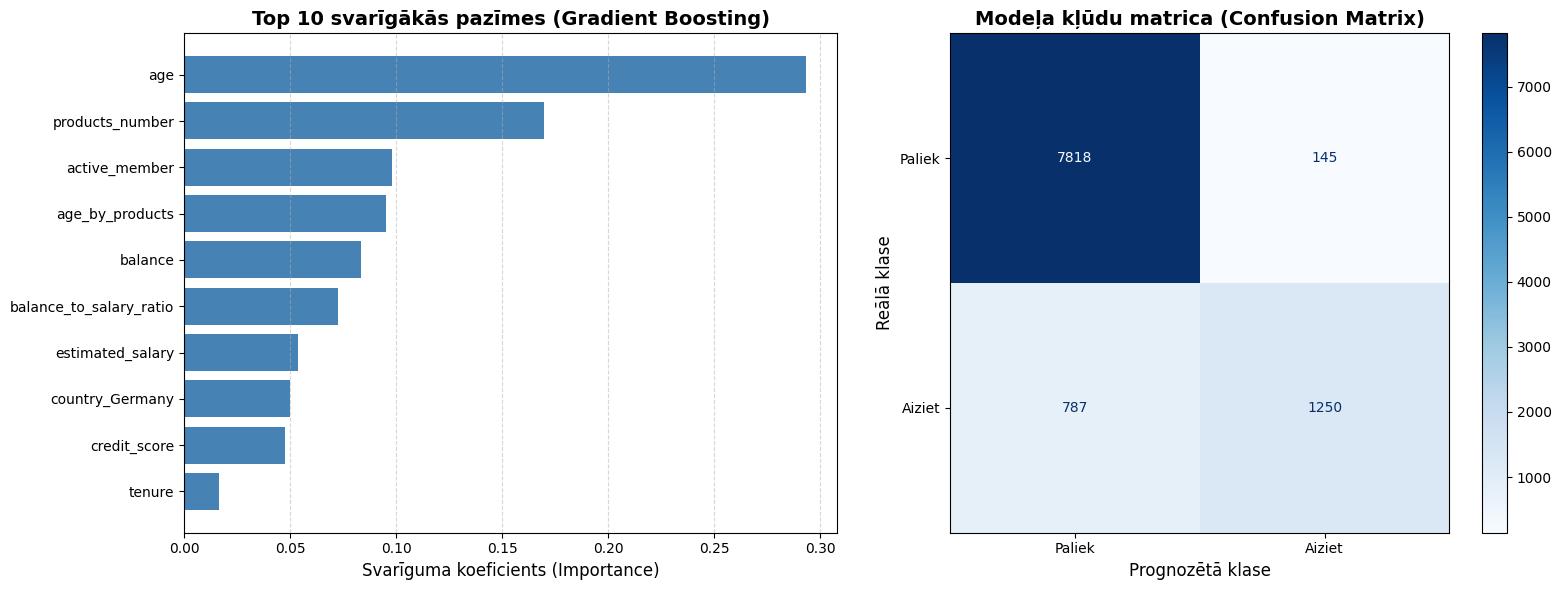


=== DETALIZĒTA KLASIFIKĀCIJAS ATSKAITE (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

      Paliek       0.91      0.98      0.94      7963
      Aiziet       0.90      0.61      0.73      2037

    accuracy                           0.91     10000
   macro avg       0.90      0.80      0.84     10000
weighted avg       0.91      0.91      0.90     10000



In [7]:
# ==============================================================================
# 8. uzdevums. Modeļa interpretācija un rezultātu vizualizācija
# ==============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# 8.1. Feature Importance (vai koeficienti)

# Iegūstam labāko apmācīto modeli no GridSearchCV (GradientBoosting)
best_pipeline = grid_search.best_estimator_

# No pipeline izvelkam pašu modeli un priekšapstrādes soli, lai dabūtu pazīmju nosaukumus
model_step = best_pipeline.named_steps['gradientboostingclassifier']
preprocessor_step = best_pipeline.named_steps['columntransformer']

# Dabūjam One-Hot kodēto kategorisko pazīmju nosaukumus
cat_encoder = preprocessor_step.named_transformers_['cat'].named_steps['onehotencoder']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()

# Apvienojam visus nosaukumus kopā precīzā secībā, kādā tie ieiet modelī
all_feature_names = numerical_cols + encoded_cat_cols

# Iegūstam pazīmju svarus (Feature Importances)
importances = model_step.feature_importances_

# Sakārtojam pazīmes dilstošā secībā
indices = np.argsort(importances)[::-1]
sorted_names = [all_feature_names[i] for i in indices]
sorted_importances = importances[indices]

# 8.2. Galvenā novērtēšanas vizualizācija

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafiks: Feature Importance (Top 10)
ax[0].barh(sorted_names[:10][::-1], sorted_importances[:10][::-1], color='steelblue')
ax[0].set_title('Top 10 svarīgākās pazīmes (Gradient Boosting)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Svarīguma koeficients (Importance)', fontsize=12)
ax[0].grid(axis='x', linestyle='--', alpha=0.5)

# Grafiks: Confusion Matrix
# Lai parādītu Confusion Matrix, vizualizējam prognozes uz visiem datiem
ConfusionMatrixDisplay.from_estimator(
    best_pipeline, X, y,
    display_labels=['Paliek', 'Aiziet'],
    cmap='Blues',
    ax=ax[1]
)
ax[1].set_title('Modeļa kļūdu matrica (Confusion Matrix)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Prognozētā klase', fontsize=12)
ax[1].set_ylabel('Reālā klase', fontsize=12)

plt.tight_layout()
plt.show()

# Izdrukājam detalizētu klasifikācijas atskaiti biznesa analīzei
print("\n=== DETALIZĒTA KLASIFIKĀCIJAS ATSKAITE (CLASSIFICATION REPORT) ===")
y_pred = best_pipeline.predict(X)
print(classification_report(y, y_pred, target_names=['Paliek', 'Aiziet']))

### 8.3. Galīgie secinājumi un projekta interpretācija

* **Ko modelis iemācījās?**
    Optimizētais *Gradient Boosting* modelis kā pašu svarīgāko pazīmi klientu uzvedībā ir identificējis **klienta vecumu (`age`)**, kam ar ievērojamu svaru seko **izmantoto produktu skaits (`products_number`)**, klienta aktivitātes statuss (`active_member`) un mūsu jaunizveidotā interakcijas pazīme **`age_by_products`**. Tas pilnībā apstiprina EDA posma pieņēmumus: vecāka gadagājuma klienti, kuriem ir neoptimāls produktu skaits un zema ikdienas aktivitāte, ir visizteiktākā riska grupa bankas pamešanai.

* **Kur modelis kļūdās?**
    Skatoties uz kļūdu matricu un klasifikācijas atskaiti, modelim ir izcila kopējā precizitāte (Accuracy = 0.91). Tomēr datu disbalansa dēļ prognozes mazākuma klasei (*Aiziet*) ir nevienmērīgas: modelim ir ļoti augsta precizitāte (Precision = 0.90), taču zemāks jutīgums (Recall = 0.61). Tas nozīmē, ka modelis strādā piesardzīgi — ja tas prognozē klienta aiziešanu, tam ir taisnība 90% gadījumu, taču reālajā dzīvē tas joprojām palaiž garām aptuveni 39% (787 klientus) no tiem, kuri faktiski aizplūst.

* **Vai rezultāts ir praktiski noderīgs?**
    Jā, šis rezultāts ir ļoti vērtīgs un praktiski pielietojams bankas biznesā. Tā kā modeļa Precision klasei *Aiziet* ir 90%, mārketinga nodaļa var veikt mērķtiecīgas un ekonomiski pamatotas mārketinga kampaņas — piedāvājot īpašus bonusus vai uzrunājot augsta riska klientus, banka gandrīz nemaz netērēs resursus veltīgi lojālo klientu segmentam. F1-score sasniegtais rādītājs 0.73 mazākuma klasei ir milzīgs solis uz priekšu salīdzinājumā ar bāzes modeli.

* **Nākamie soļi (Ko darītu, ja būtu vēl 2 nedēļas laika?):**
    1. **Sarežģītākas ansambļu metodes (Stacking):** Klasisko modeļu apvienošana vienā kopējā meta-modelī (`StackingClassifier`). Izmantojot *Gradient Boosting* un *Random Forest* prognozes kā jaunas pazīmes loģistiskajai regresijai, modelis spētu mācīties no abu algoritmu individuālajām kļūdām un vēl vairāk paceltu gala F1 rezultātu.
    2. **Dziļā mācīšanās (Neironu tīkli):** Izveidot un apmācīt daudzslāņu neironu tīklu (MLP), izmantojot *TensorFlow/Keras* vai *PyTorch* vidi. Neironu tīkls ar ReLU aktivizācijas funkcijām un Dropout slāņiem spētu uztvert apslēptas, augstākas kārtas nelineārās sakarības starp finanšu rādītājiem, kuras koku algoritmi var palaist garām.
    3. **Datu disbalansa un apjoma risināšana:** Pievienot papildu dinamiskos datus (klientu sūdzību vēsturi, lietotnes aktivitātes kritumu) un pielietot *SMOTE* datu sintēzi, lai mākslīgi palielinātu mazākuma klases īpatsvaru un paceltu *Recall* rādītāju virs 0.61.